# 02 — Input bit-depth sweep (PyTorch)

Sweeps input quantization in [0,2,4,8] with fixed network precision.

In [21]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [22]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs
from plots import (
    plot_metric_vs_input_bits,
    plot_delta_from_baseline,
    plot_tradeoff_with_pareto,
)

pd.set_option("display.max_columns", 200)


In [23]:

base = ExperimentConfig(
    backend="pytorch",
    device="cuda",
    batch_size=1,
    model_precision="fp16",          
    seed=42,
    num_eval_batches=1000,
)

in_bits_list = [8, 4, 2, 1] 

cfgs = [with_overrides(base, input_quant_bits=b) for b in in_bits_list]


In [24]:
records = []
for cfg in cfgs:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

Evaluating on 1000 batches...
  Batch [10/1000] Top-1: 80.00% | Top-5: 100.00% | Infer: 28.89 ms/batch
  Batch [20/1000] Top-1: 85.00% | Top-5: 95.00% | Infer: 15.61 ms/batch
  Batch [30/1000] Top-1: 90.00% | Top-5: 96.67% | Infer: 11.39 ms/batch
  Batch [40/1000] Top-1: 85.00% | Top-5: 95.00% | Infer: 9.38 ms/batch
  Batch [50/1000] Top-1: 88.00% | Top-5: 96.00% | Infer: 8.15 ms/batch
  Batch [60/1000] Top-1: 85.00% | Top-5: 95.00% | Infer: 7.43 ms/batch
  Batch [70/1000] Top-1: 84.29% | Top-5: 95.71% | Infer: 6.66 ms/batch
  Batch [80/1000] Top-1: 85.00% | Top-5: 95.00% | Infer: 6.20 ms/batch
  Batch [90/1000] Top-1: 84.44% | Top-5: 95.56% | Infer: 5.93 ms/batch
  Batch [100/1000] Top-1: 85.00% | Top-5: 96.00% | Infer: 5.60 ms/batch
  Batch [110/1000] Top-1: 83.64% | Top-5: 95.45% | Infer: 5.26 ms/batch
  Batch [120/1000] Top-1: 82.50% | Top-5: 95.83% | Infer: 5.08 ms/batch
  Batch [130/1000] Top-1: 82.31% | Top-5: 96.15% | Infer: 4.98 ms/batch
  Batch [140/1000] Top-1: 82.86% | Top-

In [25]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp32"]))   # include "fp16" if you enabled it
    & (df["cfg.input_quant_bits"].isin([0, 8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "cfg.model_precision",
    "cfg.input_quant_bits",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["cfg.model_precision", "cfg.input_quant_bits"])

,run_id,cfg.model_precision,cfg.input_quant_bits,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
4,resnet18_pytorch_fp32_in1b_cuda_bs1,fp32,1,0.8,4.6,2.951808,338.775472,1000
5,resnet18_pytorch_fp32_in2b_cuda_bs1,fp32,2,35.2,55.6,2.815437,355.184685,1000
6,resnet18_pytorch_fp32_in4b_cuda_bs1,fp32,4,83.6,94.9,2.829493,353.420174,1000
7,resnet18_pytorch_fp32_in8b_cuda_bs1,fp32,8,84.8,95.9,2.832111,353.093486,1000


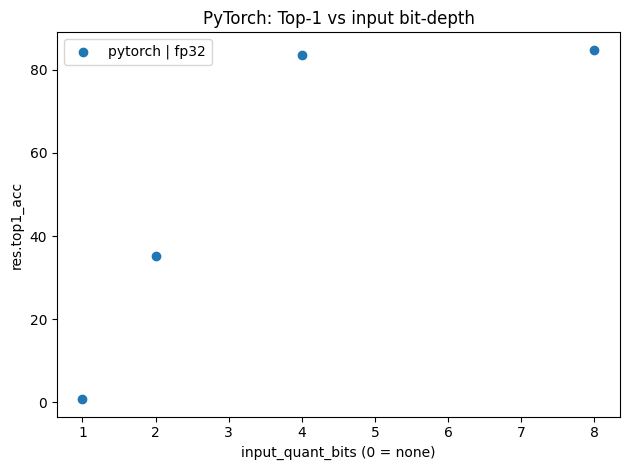

ValueError: No baseline found for selector: {'cfg.backend': 'pytorch', 'cfg.model_precision': 'fp32', 'cfg.input_quant_bits': 0, 'cfg.device': 'cuda'}

In [26]:
rows_sweep = df_sweep.to_dict(orient="records")

plot_metric_vs_input_bits(
    rows_sweep,
    metric_key="res.top1_acc",
    title="PyTorch: Top-1 vs input bit-depth",
    connect_points=False,
)

plot_delta_from_baseline(
    rows_sweep,
    baseline_selector={
        "cfg.backend": "pytorch",
        "cfg.model_precision": "fp32",
        "cfg.input_quant_bits": 0,
        "cfg.device": "cuda",
    },
    title="Input quantization sweep vs FP32 baseline",
)

plot_tradeoff_with_pareto(
    rows_sweep,
    x_key="res.infer_ms_avg",
    y_key="res.top1_acc",
    title="Input quantization: Accuracy–Latency tradeoff (Pareto)",
)